# Data Modeling

## Model Selection

### Grid Search

In [1]:
import sklearn.datasets as datasets
import sklearn.model_selection as model_selection
import sklearn.preprocessing as preprocessing
import sklearn.linear_model as linear_model
import sklearn.svm as svm
import sklearn.metrics as metrics
import sklearn.pipeline as pipeline

In [2]:
X,y = datasets.load_breast_cancer( return_X_y = True )

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,y,
    test_size = 0.25,
    random_state = 42,
    stratify = y
)

pipe = pipeline.Pipeline([
    ("scaler", preprocessing.StandardScaler()),
    ("model", svm.SVC())
])

param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1],
    "model__kernel": ["rbf"]
}

grid = model_selection.GridSearchCV(
    estimator = pipe,
    param_grid = param_grid,
    cv = 5,
    scoring = ["accuracy", "roc_auc"],
    refit = "accuracy",
    n_jobs = -1
)

grid.fit(X_train, y_train)

print(
    f"最佳参数: {grid.best_params_}",
    f"最佳交叉验证分数: {grid.best_score_}",
    sep = "\n-----\n"
)

y_pred = grid.predict(X_test)
print(
    f"测试集accuracy: {metrics.accuracy_score(y_test, y_pred)}",
    metrics.classification_report(y_test, y_pred),
    sep = "\n-----\n"
)

最佳参数: {'model__C': 1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
-----
最佳交叉验证分数: 0.9718194254445965
测试集accuracy: 0.972027972027972
-----
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        53
           1       0.97      0.99      0.98        90

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



In [3]:
print(
    grid.best_score_,
    grid.best_estimator_,
)

0.9718194254445965 Pipeline(steps=[('scaler', StandardScaler()), ('model', SVC(C=1, gamma=0.01))])


In [4]:
grid.cv_results_

{'mean_fit_time': array([0.00483027, 0.00392308, 0.00606737, 0.00588875, 0.00469704,
        0.00270414, 0.00362654, 0.00591483, 0.00280495, 0.00160375,
        0.00322561, 0.00601573, 0.00289302, 0.00236063, 0.00255036,
        0.00459576]),
 'std_fit_time': array([0.00052247, 0.00092755, 0.0008511 , 0.00136721, 0.00138389,
        0.00116715, 0.00080315, 0.00180208, 0.00097698, 0.00037427,
        0.00119872, 0.0023082 , 0.00137262, 0.00107931, 0.00017926,
        0.00036781]),
 'mean_score_time': array([0.0050014 , 0.00648885, 0.00854931, 0.00772867, 0.00755982,
        0.00401802, 0.00456986, 0.00740991, 0.00361366, 0.00260768,
        0.00391345, 0.00753517, 0.00282083, 0.00237107, 0.00345654,
        0.00577807]),
 'std_score_time': array([0.00107875, 0.00166717, 0.00380637, 0.00163273, 0.00103202,
        0.00131159, 0.00084888, 0.00083122, 0.00097745, 0.00106778,
        0.00058482, 0.00232041, 0.0007336 , 0.00030643, 0.00024088,
        0.00077266]),
 'param_model__C': masked_

### RandomSearchCV

In [7]:
import scipy.stats as stats

X,y = datasets.load_breast_cancer( return_X_y=True )

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,y,
    test_size = 0.25,
    random_state = 42,
    stratify = y
)

pipe = pipeline.Pipeline([
    ("scaler", preprocessing.StandardScaler()),
    ("model", svm.SVC())
])

param_distributions = [{
    "model__C": stats.loguniform(1e-3, 1e3),
    "model__gamma": stats.loguniform(1e-4, 1e1),
    "model__kernel": ["rbf"]
}]

random_search = model_selection.RandomizedSearchCV(
    estimator =  pipe,
    param_distributions = param_distributions,
    n_iter = 50,
    cv = 5,
    scoring = "accuracy",
    random_state = 42,
    n_jobs = -1
)

random_search.fit(X_train, y_train)

print(
    f"最佳参数: {random_search.best_params_}",
    f"最佳CV Accuracy: {random_search.best_score_}",
    sep = "\n-----\n"
)

y_pred = random_search.predict(X_test)
print(f"测试集 Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(metrics.classification_report(y_test, y_pred))

最佳参数: {'model__C': np.float64(42.425022382673205), 'model__gamma': np.float64(0.00023454342277260534), 'model__kernel': 'rbf'}
-----
最佳CV Accuracy: 0.9765253077975377
测试集 Accuracy: 0.9790209790209791
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        53
           1       0.98      0.99      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



## Linear Model

### Linear Regression

In [ ]:
import numpy as np
import sklearn.linear_model as linear_model

In [ ]:
X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5]
])

y = np.array([2,4,6,8,10])

In [ ]:
model = linear_model.LinearRegression()
model.fit(X,y)

print(model.coef_, model.intercept_, sep="\n-----\n")

[2.]
-----
0.0


In [ ]:
X_new = np.array([
    [6],
    [7]
])

y_pred = model.predict(X_new)
print(y_pred)

[12. 14.]


##### Mini Project (1)

In [ ]:
import sklearn.datasets as datasets
import sklearn.model_selection as model_selection
import sklearn.preprocessing as preprocessing
import sklearn.pipeline as pipeline

In [ ]:
# 加载数据
X,y = datasets.load_diabetes(
    return_X_y = True
)

# 划分数据集
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y,
    test_size = 0.2,
    shuffle = True,
    random_state = 42
)

print(
    X,y,sep="\n-----\n"
)

[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]
-----
[151.  75. 141. 206. 135.  97. 138.  63. 110. 310. 101.  69. 179. 185.
 118. 171. 166. 144.  97. 168.  68.  49.  68. 245. 184. 202. 137.  85.
 131. 283. 129.  59. 341.  87.  65. 102. 265. 276. 252.  90. 100.  55.
  61.  92. 259.  53. 190. 142.  75. 142. 155. 225.  59. 104. 182. 128.
  52.  37. 170. 170.  61. 144.  52. 128.  71. 163. 150.  97. 160. 178.
  48. 270. 202. 111.  85.  42. 170. 200. 252. 113. 143.  51.  52. 210.
  65. 141.  55. 134.  42. 111.  98. 164.  48.  96.  90. 162. 150. 279.
  92.

In [ ]:
pipe = pipeline.Pipeline(
    steps = [
        ("scaler", preprocessing.StandardScaler()),
        ("model", linear_model.LinearRegression())
    ]
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_pred2 = pipe.named_steps["model"].predict(pipe.named_steps["scaler"].transform(X_test))
print(y_pred == y_pred2, y_pred, y_pred2,
      sep = "\n-----\n"
)

r2 = pipe.score(X_test, y_test)
print(r2)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True]
-----
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858
  94.13865744 168.43486358  53.5047888  206.63081659 100.12925869
 130.66657085 219.53071499 250.7803234  196.3688346  218.57511815
 207.35050182  88.48340941  70.43285917 188.95914235 154.8868162
 159.36170122 188.31263363 180.39094033  47.99046561 108.97453871
 174.77897633  86.36406656 132.95761215 184.53819483 173

#### Mini Project (2)

In [ ]:
import sklearn.datasets as datasets
import sklearn.model_selection as model_selection
import sklearn.impute as impute
import sklearn.preprocessing as preprocessing
import sklearn.compose as compose
import sklearn.linear_model as linear_model
import sklearn.pipeline as pipeline

In [ ]:
# numeric_features = ["area", "age", "distance"]
# categorial_features = ["city", "house_type"]

# numeric_pipe = pipeline.Pipeline([
#     ("impute", impute.SimpleImputer(strategy="median")),
#     ("scaler", preprocessing.StandardScaler())
# ])

# categorial_pipe = pipeline.Pipeline([
#     ("impute", impute.SimpleImputer(strategy="most_frequent")),
#     ("encoder", preprocessing.OneHotEncoder(handle_unknown="ignore"))
# ])

# preprocess = compose.ColumnTransformer([
#     ("num", numeric_pipe, numeric_features),
#     ("cat", categorial_pipe, categorial_features)
# ])

# model = pipeline.Pipeline([
#     ("preprocess", preprocess),
#     ("regressor", linear_model.LinearRegression())
# ])

In [ ]:
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

### LASSO Regression

In [ ]:
X,y = datasets.load_diabetes(
    return_X_y = True
)
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y,
    test_size = 0.2,
    shuffle = True,
    random_state = 42
)
model = linear_model.Lasso( alpha = 0.1 )
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = model.score(X_test, y_test)
print(
    "测试集 R2:", r2, "\n",
    "系数:", model.coef_, "\n",
    "截距:", model.intercept_, "\n",
    "非零系数数量:", (model.coef_ != 0).sum()
)

测试集 R2: 0.4718547867276227 
 系数: [   0.         -152.66477923  552.69777529  303.36515791  -81.36500664
   -0.         -229.25577639    0.          447.91952518   29.64261704] 
 截距: 151.57485282893947 
 非零系数数量: 7


### Rigde Regression

In [ ]:
X,y = datasets.load_diabetes(
    return_X_y = True
)

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y,
    test_size = 0.2,
    shuffle = True,
    random_state = 42
)

In [ ]:
model = linear_model.Ridge(
    alpha = 1.0
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = model.score(X_test, y_test)
print(
    "测试集 R^2 ", r2, "\n"
    "系数：", model.coef_, "\n"
    "截距: ", model.intercept_, "\n"
)

测试集 R^2  0.41915292635986545 
系数： [  45.36737726  -76.66608563  291.33883165  198.99581745   -0.53030959
  -28.57704987 -144.51190505  119.26006559  230.22160832  112.14983004] 
截距:  152.241675211113 



### ElasticNet Regression

In [ ]:
X,y = datasets.load_diabetes(
    return_X_y = True,
)
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y,
    test_size = 0.2,
    shuffle = True,
    random_state = 42
)
model = linear_model.ElasticNet(
    alpha = 0.1,
    l1_ratio = 0.5
)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
r2 = model.score(X_test, y_test)

print(
    "测试集 R^2:", r2, "\n",
    "系数:", model.coef_, "\n",
    "截距:", model.intercept_, "\n",
    "非零系数数量:", (model.coef_ != 0).sum()
)

测试集 R^2: 0.09865421116113748 
 系数: [ 1.08309211e+01 -9.51378929e-03  3.89068647e+01  2.87792332e+01
  1.03720066e+01  7.19189161e+00 -2.35109789e+01  2.56271600e+01
  3.50737451e+01  2.40712511e+01] 
 截距: 153.50994400357047 
 非零系数数量: 10


#### Mini Project

In [ ]:
X,y = datasets.load_diabetes(
    return_X_y = True
)
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    shuffle = True
)
models = {
    "LinearRegression": linear_model.LinearRegression(),
    "Ridge": linear_model.Ridge( alpha=1 ),
    "Lasso": linear_model.Lasso( alpha=1 ),
    "ElasticNet": linear_model.ElasticNet( alpha=0.1, l1_ratio=0.5 )
}

In [ ]:
for name, model in models.items():
    pipe = pipeline.Pipeline([
        ("scaler", preprocessing.StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    score = pipe.score(X_test, y_test)
    coef = pipe.named_steps["model"].coef_

    print(
        "R^2: ", score,
        "非零系数量: ", (coef != 0).sum(),
        "\n" + "-"*30 + "\n"
    )


R^2:  0.4526027629719195 非零系数量:  10 
------------------------------

R^2:  0.45414652070698236 非零系数量:  10 
------------------------------

R^2:  0.46687670944102466 非零系数量:  9 
------------------------------

R^2:  0.45896958196783777 非零系数量:  10 
------------------------------



### Logistic Regression

In [ ]:
X,y = datasets.load_iris(
    return_X_y = True
)

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    shuffle = True,
    stratify = y
)

model = linear_model.LogisticRegression(
    max_iter = 1000
)

In [ ]:
print(y.shape, y_train.shape, (y_train == 0).sum(), (y_train == 1).sum(), (y_train == 2).sum())

(150,) (120,) 40 40 40


In [ ]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

acc = model.score(X_test, y_test)

print(
    "预测类别: ", y_pred[:10],
    "真实类别: ", y_test[:10],
    "测试集 accuracy: ", acc,
)

预测类别:  [0 2 1 1 0 1 0 0 2 1] 真实类别:  [0 2 1 1 0 1 0 0 2 1] 测试集 accuracy:  0.9666666666666667


#### Mini Project

In [ ]:
import pandas as pd

data = datasets.load_iris(
    as_frame = True
)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    shuffle = True,
    stratify = y
)

print(type(X_train), X_train)

<class 'pandas.DataFrame'>      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
8                  4.4               2.9                1.4               0.2
106                4.9               2.5                4.5               1.7
76                 6.8               2.8                4.8               1.4
9                  4.9               3.1                1.5               0.1
89                 5.5               2.5                4.0               1.3
..                 ...               ...                ...               ...
37                 4.9               3.6                1.4               0.1
2                  4.7               3.2                1.3               0.2
33                 5.5               4.2                1.4               0.2
52                 6.9               3.1                4.9               1.5
3                  4.6               3.1                1.5               0.2

[120 rows x 4 columns]


In [ ]:
pipe = pipeline.Pipeline([
    ("scaler", preprocessing.StandardScaler()),
    ("model", linear_model.LogisticRegression(max_iter=1000))
])
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)
acc = pipe.score(X_test, y_test)

print(
    "预测类别: ", y_pred[:10],
    "预测概率: ", proba[:5],
    "accuracy: ", acc,
    sep = "\n-----\n"
)

预测类别: 
-----
[0 2 1 1 0 1 0 0 2 1]
-----
预测概率: 
-----
[[9.78818005e-01 2.11816311e-02 3.63821812e-07]
 [3.79836951e-03 3.69220168e-01 6.26981463e-01]
 [1.48799040e-01 8.42474895e-01 8.72606441e-03]
 [9.54449962e-02 8.94618634e-01 9.93636953e-03]
 [9.88493051e-01 1.15067767e-02 1.72549650e-07]]
-----
accuracy: 
-----
0.9333333333333333


In [ ]:
clf = pipe.named_steps["model"]
coef_df = pd.DataFrame(
    data = clf.coef_,
    columns = X.columns,
    index = clf.classes_
)
coef_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-1.088945,1.024208,-1.799056,-1.686228
1,0.536337,-0.360487,-0.204074,-0.807957
2,0.552608,-0.663721,2.003130,2.494185


In [ ]:
clf.coef_

array([[-1.08894494,  1.02420763, -1.79905609, -1.68622819],
       [ 0.53633654, -0.36048698, -0.20407418, -0.80795703],
       [ 0.5526084 , -0.66372065,  2.00313027,  2.49418523]])

## Neighbors Model

### KNN

#### KNN Classifier

In [ ]:
import sklearn.neighbors as neighbors

In [ ]:
X,y = datasets.load_iris( return_X_y = True )
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    shuffle = True,
    stratify = y
)

model = neighbors.KNeighborsClassifier(
    n_neighbors = 5
)

model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
y_pred = model.predict(X_test)
acc = model.score(X_test, y_test)

print(
    "类别预测: ", y_pred,
    "真实预测: ", y_test,
    "测试集 accuracy: ", acc,
    sep = "\n-----\n"
)

类别预测: 
-----
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
-----
真实预测: 
-----
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
-----
测试集 accuracy: 
-----
1.0


## Tree Model

### Decision Tree

#### Classifier

In [ ]:
import sklearn.tree as tree
import matplotlib.pyplot as plt

In [ ]:
X,y = datasets.load_iris( return_X_y = True )
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    shuffle = True,
    stratify = y
)

model = tree.DecisionTreeClassifier(
    max_depth = 3,
    random_state = 42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = model.score(X_test, y_test)

print(
    "预测类别: ", y_pred[:10], 
    "真实类别: ", y_test[:10],
    "测试集 accuracy: ", acc,
    "特征重要性: ", model.feature_importances_,
    sep = "\n-----\n"
)

预测类别: 
-----
[0 2 1 1 0 1 0 0 2 1]
-----
真实类别: 
-----
[0 2 1 1 0 1 0 0 2 1]
-----
测试集 accuracy: 
-----
0.9666666666666667
-----
特征重要性: 
-----
[0.         0.         0.57907728 0.42092272]


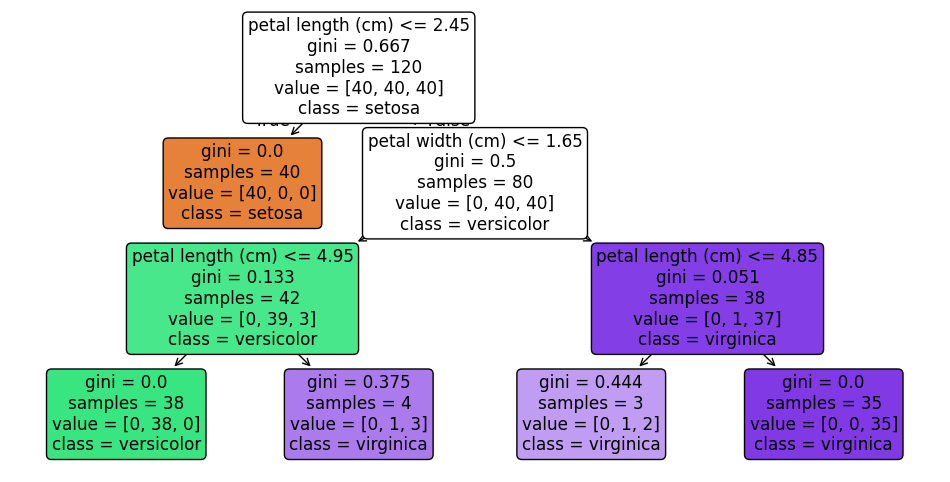

In [ ]:
data = datasets.load_iris( as_frame = True )
X = data.data
y = data.target

plt.figure(figsize=(12,6))
tree.plot_tree(
    decision_tree = model,
    feature_names = X.columns,
    class_names = data.target_names,
    filled = True,
    rounded = True
)
plt.show()
plt.close()

### Random Forest

In [ ]:
import sklearn.ensemble as ensemble

In [ ]:
X,y = datasets.load_iris( return_X_y = True )
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    shuffle = True,
    stratify = y
)

model = ensemble.RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_train)
acc = model.score(X_test, y_test)

print(
    "实际类别: ", y_test[:10],
    "预测类别: ", y_pred[:10],
    "测试集 accuracy: ", acc,
    "特征重要性: ", model.feature_importances_,
    sep = "\n-----\n"
)

实际类别: 
-----
[0 2 1 1 0 1 0 0 2 1]
-----
预测类别: 
-----
[0 2 1 0 1 2 1 2 2 2]
-----
测试集 accuracy: 
-----
0.9
-----
特征重要性: 
-----
[0.11634851 0.01499973 0.43146641 0.43718536]


## SVM Model

## Bayes Model

In [ ]:
import sklearn.naive_bayes as naive_bayes

### GaussianNB

In [ ]:
X,y = datasets.load_iris( return_X_y = True )

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    shuffle = True,
    stratify = y
)

model = naive_bayes.GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = model.score(X_test, y_test)

In [ ]:
print(
    "预测类别: ", y_pred[:10],
    "真实类别: ", y_test[:10],
    "测试集 accuracy: ", acc,
    sep = "\n-----\n"
)

预测类别: 
-----
[0 2 1 1 0 1 0 0 2 1]
-----
真实类别: 
-----
[0 2 1 1 0 1 0 0 2 1]
-----
测试集 accuracy: 
-----
0.9666666666666667


## Ensemble Model

#### Bagging Model

##### Bagging Classifier

In [ ]:
import sklearn.ensemble as ensemble

In [ ]:
X,y = datasets.load_iris( return_X_y = True )
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    shuffle = True,
    stratify = y
)

model = ensemble.BaggingClassifier(
    estimator = tree.DecisionTreeClassifier(),
    n_estimators = 50,
    random_state = 42,
    n_jobs = -1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print("accuracy: ", model.score(X_test, y_test), sep = "\n-----\n")

accuracy: 
-----
0.9666666666666667


##### Bagging Regressor

In [ ]:
X,y = datasets.load_diabetes( return_X_y=True )
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42
)

model = ensemble.BaggingRegressor(
    estimator = tree.DecisionTreeRegressor(),
    n_estimators = 50,
    random_state = 42,
    n_jobs = -1
)

model.fit(X_train, y_train),
y_pred = model.predict(X_test),
print("R^2: ", model.score(X_test, y_test))

R^2:  0.4231017254077404


### Boosting Model

#### Adaboost

In [ ]:
X,y = datasets.load_iris( return_X_y = True )
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

model = ensemble.AdaBoostClassifier(
    estimator = tree.DecisionTreeClassifier(max_depth=3),
    n_estimators = 50,
    learning_rate = 1.0,
    random_state = 42
)

model.fit(X_train, y_train)
print("accuracy: ", model.score(X_test, y_test))

accuracy:  0.9666666666666667


#### Gradientboost

In [ ]:
X, y = datasets.load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = ensemble.GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("accuracy:", model.score(X_test, y_test))

accuracy: 0.9666666666666667


In [ ]:
X, y = datasets.load_diabetes(return_X_y=True)

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = ensemble.GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("R²:", model.score(X_test, y_test))

R²: 0.4529343796683364


## Non-Supervised Model

### K-Means Clustering

In [ ]:
import sklearn.cluster as cluster

In [ ]:
X,_ = datasets.make_blobs(
    n_samples = 300,
    centers = 3,
    cluster_std = 1.0,
    random_state = 42
)

model = cluster.KMeans(
    n_clusters = 3,
    random_state = 42,
    n_init = "auto"
)

labels = model.fit_predict(X)
print(
    "前10个样本的簇编号: ", labels[:10],
    "簇中心: ", model.cluster_centers_,
    "inertia: ", model.inertia_,
    sep = "\n-----\n"
)

前10个样本的簇编号: 
-----
[1 1 0 2 1 2 0 2 0 0]
-----
簇中心: 
-----
[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]
-----
inertia: 
-----
566.8595511244131


### PCA

In [ ]:
import sklearn.decomposition as decomposition

In [ ]:
X,y = datasets.load_iris( return_X_y=True )
pipe = pipeline.Pipeline([
    ("scaler", preprocessing.StandardScaler()),
    ("pca", decomposition.PCA(n_components=2))
])

X_pca = pipe.fit_transform(X)
print(
    "原始X形状: ", X.shape,
    "降维后形状: ", X_pca.shape
)

原始X形状:  (150, 4) 降维后形状:  (150, 2)
